In [1]:
!pip install medmnist

In [2]:
!pip install libauc==1.2.0

In [3]:
!pip install pytorchtools

In [4]:
'''
Steps
1. Data shifting (balance data if imblance by downsampling)
2. Data augmentation
--a) do only Gaussian noise
--b) do only Flipping/mirroring
--c) do only Rotation
--d) do only Normalizing
--e) do all augmentation techniques at the same time
3. Go back to step 1 or 2 and repeat (for data-centric approach)
4. Optimizer
5. Hyperparameter tuning (w/o hyper parameter tuning) and model training and testing with the best dataset
'''
pass

In [5]:
from sklearn import metrics
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms

import medmnist
from medmnist import INFO, Evaluator

In [6]:
from libauc.losses import AUCMLoss
from libauc.optimizers import PESG, Adam, SGD
from libauc.models import resnet20 as ResNet20
from libauc.datasets import CIFAR10
from libauc.utils import ImbalancedDataGenerator
from libauc.sampler import DualSampler
from libauc.metrics import auc_roc_score

import torch 
from PIL import Image
import numpy as np
import torchvision.transforms as transforms
from torch.utils.data import Dataset
from sklearn.metrics import roc_auc_score
from torch.utils.tensorboard import SummaryWriter
#from pytorchtools import EarlyStopping
import sys
     

In [7]:
import matplotlib.pyplot as plt

In [8]:
#data_flag = 'pathmnist'
data_flag = 'breastmnist'
download = True

NUM_EPOCHS = 3
BATCH_SIZE = 128
lr = 0.001

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

In [9]:
# preprocessing
'''
data_transform1 = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Grayscale(3),
    transforms.ToTensor()
])
'''
data_transform1 = transforms.Compose([
    transforms.ToTensor()
])


In [10]:
'''
def add_noise(inputs,noise_factor=0.3):
     noisy = inputs+torch.randn_like(inputs) * noise_factor
     noisy = torch.clip(noisy,0.,1.)
     return noisy
'''
'''
examples1 = iter(train_loader1)
samples1, labels1 = next(examples1)
noise_imgs = add_noise(samples1[0][0],noise_factor=0.3)

noise_imgs = [add_noise(T.ToTensor()(orig_img),noise_factor) for noise_factor in (0.3,0.6,0.9)]
#noise_imgs = [T.ToPILImage()(noise_img) for noise_img in noise_imgs]
plot(noise_imgs, col_title=["noise_factor=0.3","noise_factor=0.6","noise_factor=0.9"])
'''

'\nexamples1 = iter(train_loader1)\nsamples1, labels1 = next(examples1)\nnoise_imgs = add_noise(samples1[0][0],noise_factor=0.3)\n\nnoise_imgs = [add_noise(T.ToTensor()(orig_img),noise_factor) for noise_factor in (0.3,0.6,0.9)]\n#noise_imgs = [T.ToPILImage()(noise_img) for noise_img in noise_imgs]\nplot(noise_imgs, col_title=["noise_factor=0.3","noise_factor=0.6","noise_factor=0.9"])\n'

In [11]:
# load the data
#train_dataset = DataClass(split='train', transform=data_transform, download=download)

train_dataset1 = DataClass(split='train', transform=data_transform1, download=download)
val_dataset1 = DataClass(split='val', transform=data_transform1, download=download)
test_dataset = DataClass(split='test', transform=data_transform1, download=download)

#pil_dataset = DataClass(split='train', download=download)
train_dataset1

Using downloaded and verified file: /Users/chihoonlee/.medmnist/breastmnist.npz
Using downloaded and verified file: /Users/chihoonlee/.medmnist/breastmnist.npz
Using downloaded and verified file: /Users/chihoonlee/.medmnist/breastmnist.npz


Dataset BreastMNIST (breastmnist)
    Number of datapoints: 546
    Root location: /Users/chihoonlee/.medmnist
    Split: train
    Task: binary-class
    Number of channels: 1
    Meaning of labels: {'0': 'malignant', '1': 'normal, benign'}
    Number of samples: {'train': 546, 'val': 78, 'test': 156}
    Description: The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.
    License: CC BY 4.0

In [12]:
'''
#train alone
train_loader1 = data.DataLoader(dataset=train_dataset1, batch_size=BATCH_SIZE, shuffle=True)

tr_iter = iter(train_loader1)
examples, labels = next(tr_iter)
tr_tensors_img, tr_tensors_labels = examples, labels
for i in range(1, ceil(len(train_dataset1) / BATCH_SIZE)):
    examples, labels = next(tr_iter)
    tr_tensors_img = torch.cat([tr_tensors_img, examples])
    tr_tensors_labels = torch.cat([tr_tensors_labels, labels])
'''

'\n#train alone\ntrain_loader1 = data.DataLoader(dataset=train_dataset1, batch_size=BATCH_SIZE, shuffle=True)\n\ntr_iter = iter(train_loader1)\nexamples, labels = next(tr_iter)\ntr_tensors_img, tr_tensors_labels = examples, labels\nfor i in range(1, ceil(len(train_dataset1) / BATCH_SIZE)):\n    examples, labels = next(tr_iter)\n    tr_tensors_img = torch.cat([tr_tensors_img, examples])\n    tr_tensors_labels = torch.cat([tr_tensors_labels, labels])\n'

In [14]:
# encapsulate data into dataloader form
train_loader1 = data.DataLoader(dataset=train_dataset1, batch_size=BATCH_SIZE, shuffle=True)
val_loader1 = data.DataLoader(dataset=val_dataset1, batch_size=BATCH_SIZE, shuffle=True)
#train_loader2 = data.DataLoader(dataset=train_dataset2, batch_size=BATCH_SIZE, shuffle=True)
#train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
#test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

Step 1: Data shifting (balance data if imblance by upsampling)

In [15]:
# combine train and validation datasets to check class ratio
from math import ceil

combined_train = torch.utils.data.ConcatDataset([train_dataset1, val_dataset1])
ct_loader = data.DataLoader(dataset=combined_train, batch_size=BATCH_SIZE, shuffle=True)
ct_iter = iter(ct_loader)
print(len(combined_train))
examples, labels = next(ct_iter)
ct_tensors_img, ct_tensors_labels = examples, labels
for i in range(1, ceil(len(combined_train) / BATCH_SIZE)):
    examples, labels = next(ct_iter)
    ct_tensors_img = torch.cat([ct_tensors_img, examples])
    ct_tensors_labels = torch.cat([ct_tensors_labels, labels])
    #print(examples)
    #print(labels)

624


In [16]:
# data imbalance issue exists in the combined dataset, and we must address this issue
res = ct_tensors_labels.unique(return_counts=True)
print(res)
neg_counts, pos_counts = res[1][0], res[1][1]
neg_counts

(tensor([0, 1]), tensor([168, 456]))


tensor(168)

Step 2: data augmentation

In [17]:
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=1.):
        self.std = std
        self.mean = mean
        
    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean
    
    def __repr__(self):
        return self.__class__.__name__ + '(mean={0}, std={1})'.format(self.mean, self.std)

In [18]:
# We will overcome the data imbalance issue by upsamling the minority class using data augmentation
# since the majority class is almost three times as many as the minority class, 
# two data augmentation techniques will be employed to increase the number of images in the minority class

# two augmentation combination: HorizontalFlip and Gaussian Noise
data_transform2 = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(p=1.0)
])
data_transform3 = transforms.Compose([
    transforms.ToTensor(),
    AddGaussianNoise(0., 0.2)
])

In [21]:
def create_new_img_by_augmentations(desired_class, data_transform):
    # load more training and validation dataset to create new data using data augmentation
    # param: desired_class(list) is a list of classes to be kept,
    # and all the other classes not in this list will be filtered out
    # param: data_transform(pytorch.transforms) is a data transform method to be applied to dataset
    # return: pytorch dataset
    train_dataset = DataClass(split='train', transform=data_transform)
    val_dataset = DataClass(split='val', transform=data_transform)
    filtered_trainset = torch.utils.data.Subset(train_dataset,
                            [i for i in range(len(train_dataset)) if train_dataset.labels[i] in desired_class])
    filtered_valset = torch.utils.data.Subset(val_dataset,
                            [i for i in range(len(val_dataset)) if val_dataset.labels[i] in desired_class])
    combined_train = torch.utils.data.ConcatDataset([filtered_trainset, filtered_valset])
    return combined_train

In [22]:
# load more training and validation dataset to create new data using data augmentation
desired_class = [0]
new_combined_train = torch.utils.data.ConcatDataset([create_new_img_by_augmentations(desired_class,
                                                                                     data_transform=data_transform2),
                                               create_new_img_by_augmentations(desired_class,
                                                                               data_transform=data_transform3)])
new_combined_train

In [23]:
count_diff = int(max(neg_counts, pos_counts) - min(neg_counts, pos_counts))
random_sampler = data.RandomSampler(new_combined_train, num_samples=count_diff)
added_dataloader = data.DataLoader(new_combined_train, batch_size=BATCH_SIZE, sampler=random_sampler)

In [24]:
added_diter = iter(added_dataloader)
examples, labels = next(added_diter)
added_tensors_img, added_tensors_labels = examples, labels
#for i in range(1, ceil(len(combined_train) / BATCH_SIZE)):
for i in range(1, ceil(count_diff / BATCH_SIZE)):
    examples, labels = next(added_diter)
    added_tensors_img = torch.cat([added_tensors_img, examples])
    added_tensors_labels = torch.cat([added_tensors_labels, labels])


In [26]:
#type(ct_tensors_img),ct_tensors_labels

In [27]:
X = torch.cat([ct_tensors_img, added_tensors_img])
y = torch.cat([ct_tensors_labels, added_tensors_labels])

In [28]:
# splitting train and validation data with balanced ratio
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=7)
len(X_train)

729

In [29]:
train_d = torch.utils.data.TensorDataset(X_train, y_train)
val_d = torch.utils.data.TensorDataset(X_val, y_val)


In [30]:
trainloader = data.DataLoader(dataset=train_d, batch_size=BATCH_SIZE, shuffle=True)
valloader = data.DataLoader(dataset=val_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
trainloader_eval = data.DataLoader(train_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [31]:
# step 3
# training model

def train(model, loss_fn, optimizer, total_epochs, trainloader, trainloader_eval, testloader,
          patience=20, decay_epochs=None):
    # param: model=pytorch NN model
    # param: loss_fn = loss function
    # param: optimizer = pytorch optimizer
    # param: total_epochs(int) = total epochs for training
    # param: trainloader(pytorch data loader). train dataset loader used for model training
    # param: trainloader_eval(pytorch data loader). train dataset loader used for evaluation
    # param: testloader(pytorch data loader)
    # param: patience - how long to wait after last time validation loss improved
    # param: decay_epochs is decay epochs range for decreasing the learning rate (default=None, then not used)
    # return a tuple of train_log and test_log. log arrays contain auc values from each epoch
    
    print ('Start Training')
    print ('-'*30)

    train_log = []
    test_log = []
    
    # initialize the early_stopping object
    #early_stopping = EarlyStopping(patience=patience, verbose=True)
    no_val_change_count = 0
    last_val_auc = 0
    for epoch in range(total_epochs):
        if decay_epochs is not None and epoch in decay_epochs:
            optimizer.update_regularizer(decay_factor=10) # decrease learning rate by 10x & update regularizer

        train_loss = []
        model.train()    
        for data, targets in trainloader:
            print(len(data))
            #data, targets  = data.cuda(), targets.cuda()
            y_pred = model(data)
            y_pred = torch.sigmoid(y_pred)
            loss = loss_fn(y_pred, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())

        # evaluation on train & test sets
        model.eval()
        train_pred_list = []
        train_true_list = [] 
        for train_data, train_targets in trainloader_eval:
            train_pred = model(train_data)
            #train_pred_list.append(train_pred.cpu().detach().numpy())
            #train_true_list.append(train_targets.numpy())
            train_pred_list.append(train_pred.detach().numpy())
            train_true_list.append(train_targets.numpy())
        train_true = np.concatenate(train_true_list)
        train_pred = np.concatenate(train_pred_list)
        train_auc = auc_roc_score(train_true, train_pred)
        train_loss = np.mean(train_loss)

        test_pred_list = []
        test_true_list = [] 
        for test_data, test_targets in testloader:
            test_pred = model(test_data)
            test_pred_list.append(test_pred.detach().numpy())
            test_true_list.append(test_targets.numpy())
        test_true = np.concatenate(test_true_list)
        test_pred = np.concatenate(test_pred_list)
        val_auc =  auc_roc_score(test_true, test_pred) 
        model.train()

        # print results
        print("epoch: %s, train_loss: %.4f, train_auc: %.4f, val_auc: %.4f, lr: %.4f"%(epoch, train_loss, train_auc, val_auc, optimizer.lr ))    
        train_log.append(train_auc) 
        test_log.append(val_auc)
        
        # early_stopping needs the validation loss to check if it has decresed, 
        # and if it has, it will make a checkpoint of the current model
        #early_stopping(valid_auc, model)
        if val_auc <= (last_val_auc - 1e-3*5):
            no_val_change_count += 1
        else:
            no_val_change_count = 0
        
        print(no_val_change_count)
        if no_val_change_count >= patience:
            print("Early stopping")
            break
        
        #if early_stopping.early_stop:
        #    print("Early stopping")
        #    break
    return train_log, test_log



In [34]:
# resnet18 model
from libauc.models import resnet18 as ResNet18

#writer = SummaryWriter("runs/breast")
model = ResNet18(pretrained=False, last_activation=None, num_classes=1, )
model.conv1 = torch.nn.Conv2d(1, 64, kernel_size=7, stride=1, padding=3, bias=False)

# HyperParameters
SEED = 123
BATCH_SIZE = 128
imratio = 0.1 # for demo 
total_epochs = 50
decay_epochs = [50, 75]

lr = 0.1
margin = 1.0
epoch_decay = 0.003 # refers gamma in the paper
weight_decay = 0.0001


# loss and optimizer
loss_fn = AUCMLoss()
optimizer = PESG(model, 
                 loss_fn=loss_fn,
                 lr=lr, 
                 momentum=0.9,
                 #margin=margin)
                 margin=margin, 
                 epoch_decay=epoch_decay, 
                 weight_decay=weight_decay)

#writer.add_graph(model=model)  # graph of model structure
#writer.close()
#sys.exit()



Start Training
------------------------------
128
128
128
128
128
89
epoch: 0, train_loss: 0.1684, train_auc: 0.5272, val_auc: 0.5383, lr: 0.1000
0
128
128
128
128
128
89
epoch: 1, train_loss: 0.2264, train_auc: 0.5284, val_auc: 0.6040, lr: 0.1000
0
128
128
128
128
128
89
epoch: 2, train_loss: 0.1848, train_auc: 0.6360, val_auc: 0.6694, lr: 0.1000
0
128
128
128
128
128
89
epoch: 3, train_loss: 0.1180, train_auc: 0.6590, val_auc: 0.6725, lr: 0.1000
0
128
128
128
128
128
89
epoch: 4, train_loss: 0.0713, train_auc: 0.7516, val_auc: 0.7186, lr: 0.1000
0
128
128
128
128
128
89
epoch: 5, train_loss: 0.0217, train_auc: 0.8313, val_auc: 0.7443, lr: 0.1000
0
128
128
128
128
128
89
epoch: 6, train_loss: -0.0043, train_auc: 0.9080, val_auc: 0.7861, lr: 0.1000
0
128
128
128
128
128
89
epoch: 7, train_loss: -0.0202, train_auc: 0.9973, val_auc: 0.8783, lr: 0.1000
0
128
128
128
128
128
89
epoch: 8, train_loss: -0.0181, train_auc: 1.0000, val_auc: 0.9053, lr: 0.1000
0
128
128
128
128
128
89
epoch: 9, 

AttributeError: 'Line2D' object has no property 'LineStyle'

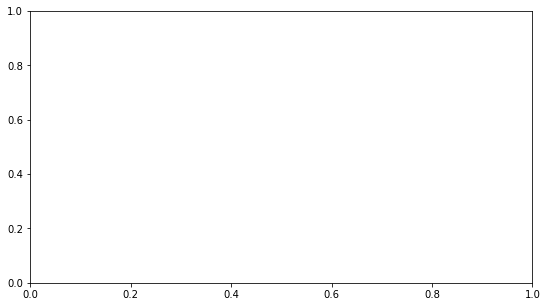

In [35]:
# early stopping patience; how long to wait after last time validation loss improved.
patience = 20

train_log, val_log = train(model, loss_fn, optimizer, total_epochs, trainloader, trainloader_eval, 
                           valloader, patience=20, decay_epochs=decay_epochs)


Text(0.5, 0, 'Epoch')

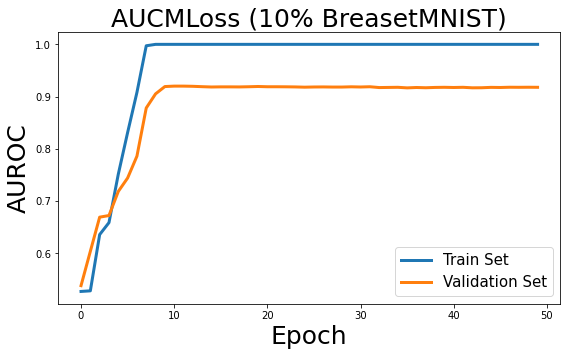

In [46]:
plt.rcParams["figure.figsize"] = (9,5)
x=np.arange(len(train_log))
plt.figure()
plt.plot(x, train_log, linestyle='-', label='Train Set', linewidth=3)
plt.plot(x, val_log,  linestyle='-', label='Validation Set', linewidth=3)
plt.title('AUCMLoss (10% BreasetMNIST)',fontsize=25)
plt.legend(fontsize=15)
plt.ylabel('AUROC', fontsize=25)
plt.xlabel('Epoch', fontsize=25)

In [47]:
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE)

In [48]:
# Testing AUC
score_list = list()
label_list = list()
for _, d in enumerate(test_loader, 0):
    tmp_data, tmp_label = d
    #tmp_data, tmp_label = tmp_data.cuda(), tmp_label.cuda()
    
    tmp_score = model(tmp_data).detach().clone().cpu()
    score_list.append(tmp_score)
    label_list.append(tmp_label.cpu())

test_label = torch.cat(label_list)
test_score = torch.cat(score_list)
                   
test_auc = metrics.roc_auc_score(test_label, test_score)                   
print("Test : %.4f"%test_auc, flush=True)

Test : 0.8074


In [49]:
# Back to Step 2
# two augmentation combination: HorizontalFlip and Normalize
data_transform2 = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(p=1.0)
])
data_transform4 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

In [50]:
# load more training and validation dataset to create new data using data augmentation
desired_class = [0]
new_combined_train = torch.utils.data.ConcatDataset([create_new_img_by_augmentations(desired_class,
                                                                                     data_transform=data_transform2),
                                               create_new_img_by_augmentations(desired_class,
                                                                               data_transform=data_transform4)])
new_combined_train

In [51]:
count_diff = int(max(neg_counts, pos_counts) - min(neg_counts, pos_counts))
random_sampler = data.RandomSampler(new_combined_train, num_samples=count_diff)
added_dataloader = data.DataLoader(new_combined_train, batch_size=BATCH_SIZE, sampler=random_sampler)

added_diter = iter(added_dataloader)
examples, labels = next(added_diter)
added_tensors_img, added_tensors_labels = examples, labels
#for i in range(1, ceil(len(combined_train) / BATCH_SIZE)):
for i in range(1, ceil(count_diff / BATCH_SIZE)):
    examples, labels = next(added_diter)
    added_tensors_img = torch.cat([added_tensors_img, examples])
    added_tensors_labels = torch.cat([added_tensors_labels, labels])
    
X = torch.cat([ct_tensors_img, added_tensors_img])
y = torch.cat([ct_tensors_labels, added_tensors_labels])

In [52]:
# splitting train and validation data with balanced ratio
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=7)
len(X_train)

729

In [53]:
train_d = torch.utils.data.TensorDataset(X_train, y_train)
val_d = torch.utils.data.TensorDataset(X_val, y_val)

In [54]:
trainloader = data.DataLoader(dataset=train_d, batch_size=BATCH_SIZE, shuffle=True)
valloader = data.DataLoader(dataset=val_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
trainloader_eval = data.DataLoader(train_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [56]:
# resnet18 model
from libauc.models import resnet18 as ResNet18

#writer = SummaryWriter("runs/breast")
model2 = ResNet18(pretrained=False, last_activation=None, num_classes=1, )
model2.conv1 = torch.nn.Conv2d(1, 64, kernel_size=7, stride=1, padding=3, bias=False)

# HyperParameters
SEED = 123
BATCH_SIZE = 128
imratio = 0.1 # for demo 
total_epochs = 50
decay_epochs = [50, 75]

lr = 0.1
margin = 1.0
epoch_decay = 0.003 # refers gamma in the paper
weight_decay = 0.0001


# loss and optimizer
loss_fn = AUCMLoss()
optimizer = PESG(model2, 
                 loss_fn=loss_fn,
                 lr=lr, 
                 momentum=0.9,
                 #margin=margin)
                 margin=margin, 
                 epoch_decay=epoch_decay, 
                 weight_decay=weight_decay)

#writer.add_graph(model=model)  # graph of model structure
#writer.close()
#sys.exit()



In [57]:
# early stopping patience; how long to wait after last time validation loss improved.
patience = 20

train_log, val_log = train(model2, loss_fn, optimizer, total_epochs, trainloader, trainloader_eval, valloader, 
     decay_epochs=decay_epochs)

Start Training
------------------------------
128
128
128
128
128
89
epoch: 0, train_loss: 0.1565, train_auc: 0.5787, val_auc: 0.5883, lr: 0.1000
0
128
128
128
128
128
89
epoch: 1, train_loss: 0.2314, train_auc: 0.6641, val_auc: 0.6910, lr: 0.1000
0
128
128
128
128
128
89
epoch: 2, train_loss: 0.1942, train_auc: 0.7548, val_auc: 0.7413, lr: 0.1000
0
128
128
128
128
128
89
epoch: 3, train_loss: 0.1341, train_auc: 0.7188, val_auc: 0.7525, lr: 0.1000
0
128
128
128
128
128
89
epoch: 4, train_loss: 0.0703, train_auc: 0.8564, val_auc: 0.8253, lr: 0.1000
0
128
128
128
128
128
89
epoch: 5, train_loss: 0.0494, train_auc: 0.8711, val_auc: 0.8201, lr: 0.1000
0
128
128
128
128
128
89
epoch: 6, train_loss: -0.0009, train_auc: 0.9385, val_auc: 0.8347, lr: 0.1000
0
128
128
128
128
128
89
epoch: 7, train_loss: -0.0138, train_auc: 0.9948, val_auc: 0.8846, lr: 0.1000
0
128
128
128
128
128
89
epoch: 8, train_loss: -0.0191, train_auc: 1.0000, val_auc: 0.9091, lr: 0.1000
0
128
128
128
128
128
89
epoch: 9, 

Text(0.5, 0, 'Epoch')

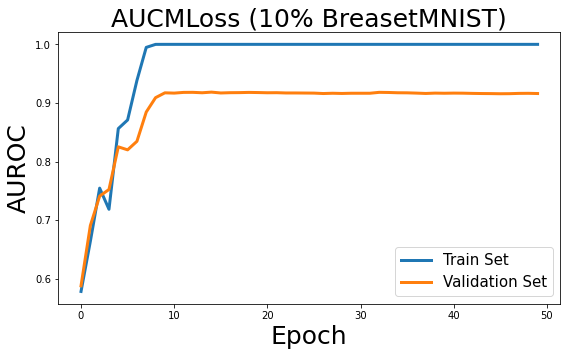

In [58]:
plt.rcParams["figure.figsize"] = (9,5)
x=np.arange(len(train_log))
plt.figure()
plt.plot(x, train_log, linestyle='-', label='Train Set', linewidth=3)
plt.plot(x, val_log,  linestyle='-', label='Validation Set', linewidth=3)
plt.title('AUCMLoss (10% BreasetMNIST)',fontsize=25)
plt.legend(fontsize=15)
plt.ylabel('AUROC', fontsize=25)
plt.xlabel('Epoch', fontsize=25)

In [59]:
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE)

# Testing AUC
score_list = list()
label_list = list()
for _, d in enumerate(test_loader, 0):
    tmp_data, tmp_label = d
    #tmp_data, tmp_label = tmp_data.cuda(), tmp_label.cuda()
    
    tmp_score = model2(tmp_data).detach().clone().cpu()
    score_list.append(tmp_score)
    label_list.append(tmp_label.cpu())

test_label = torch.cat(label_list)
test_score = torch.cat(score_list)
                   
test_auc = metrics.roc_auc_score(test_label, test_score)                   
print("Test : %.4f"%test_auc, flush=True)

Test : 0.8141


In [61]:
# Back to Step 2
# two augmentation combination: Gaussian Noise and Normalize
# load more training and validation dataset to create new data using data augmentation
desired_class = [0]
new_combined_train = torch.utils.data.ConcatDataset([create_new_img_by_augmentations(desired_class,
                                                                                     data_transform=data_transform3),
                                               create_new_img_by_augmentations(desired_class,
                                                                               data_transform=data_transform4)])
new_combined_train

In [62]:
count_diff = int(max(neg_counts, pos_counts) - min(neg_counts, pos_counts))
random_sampler = data.RandomSampler(new_combined_train, num_samples=count_diff)
added_dataloader = data.DataLoader(new_combined_train, batch_size=BATCH_SIZE, sampler=random_sampler)

added_diter = iter(added_dataloader)
examples, labels = next(added_diter)
added_tensors_img, added_tensors_labels = examples, labels
#for i in range(1, ceil(len(combined_train) / BATCH_SIZE)):
for i in range(1, ceil(count_diff / BATCH_SIZE)):
    examples, labels = next(added_diter)
    added_tensors_img = torch.cat([added_tensors_img, examples])
    added_tensors_labels = torch.cat([added_tensors_labels, labels])
    
X = torch.cat([ct_tensors_img, added_tensors_img])
y = torch.cat([ct_tensors_labels, added_tensors_labels])

In [348]:
# splitting train and validation data with balanced ratio
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=7)
len(X_train)

729

In [63]:
train_d = torch.utils.data.TensorDataset(X_train, y_train)
val_d = torch.utils.data.TensorDataset(X_val, y_val)

In [64]:
trainloader = data.DataLoader(dataset=train_d, batch_size=BATCH_SIZE, shuffle=True)
valloader = data.DataLoader(dataset=val_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
trainloader_eval = data.DataLoader(train_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [66]:
# resnet18 model
from libauc.models import resnet18 as ResNet18

#writer = SummaryWriter("runs/breast")
model3 = ResNet18(pretrained=False, last_activation=None, num_classes=1, )
model3.conv1 = torch.nn.Conv2d(1, 64, kernel_size=7, stride=1, padding=3, bias=False)

# HyperParameters
SEED = 123
BATCH_SIZE = 128
imratio = 0.1 # for demo 
total_epochs = 50
decay_epochs = [50, 75]

lr = 0.1
margin = 1.0
epoch_decay = 0.003 # refers gamma in the paper
weight_decay = 0.0001


# loss and optimizer
loss_fn = AUCMLoss()
optimizer = PESG(model3, 
                 loss_fn=loss_fn,
                 lr=lr, 
                 momentum=0.9,
                 #margin=margin)
                 margin=margin, 
                 epoch_decay=epoch_decay, 
                 weight_decay=weight_decay)

#writer.add_graph(model=model)  # graph of model structure
#writer.close()
#sys.exit()



In [67]:
# early stopping patience; how long to wait after last time validation loss improved.
patience = 20

train_log, val_log = train(model3, loss_fn, optimizer, total_epochs, trainloader, trainloader_eval, valloader,
      decay_epochs=decay_epochs)

Start Training
------------------------------
128
128
128
128
128
89
epoch: 0, train_loss: 0.1549, train_auc: 0.5988, val_auc: 0.6161, lr: 0.1000
0
128
128
128
128
128
89
epoch: 1, train_loss: 0.2235, train_auc: 0.6848, val_auc: 0.6639, lr: 0.1000
0
128
128
128
128
128
89
epoch: 2, train_loss: 0.1813, train_auc: 0.7930, val_auc: 0.7677, lr: 0.1000
0
128
128
128
128
128
89
epoch: 3, train_loss: 0.1227, train_auc: 0.8234, val_auc: 0.7999, lr: 0.1000
0
128
128
128
128
128
89
epoch: 4, train_loss: 0.0690, train_auc: 0.8481, val_auc: 0.8210, lr: 0.1000
0
128
128
128
128
128
89
epoch: 5, train_loss: 0.0320, train_auc: 0.9040, val_auc: 0.8696, lr: 0.1000
0
128
128
128
128
128
89
epoch: 6, train_loss: 0.0192, train_auc: 0.9663, val_auc: 0.8463, lr: 0.1000
0
128
128
128
128
128
89
epoch: 7, train_loss: -0.0095, train_auc: 0.9919, val_auc: 0.8635, lr: 0.1000
0
128
128
128
128
128
89
epoch: 8, train_loss: -0.0175, train_auc: 1.0000, val_auc: 0.9070, lr: 0.1000
0
128
128
128
128
128
89
epoch: 9, t

Text(0.5, 0, 'Epoch')

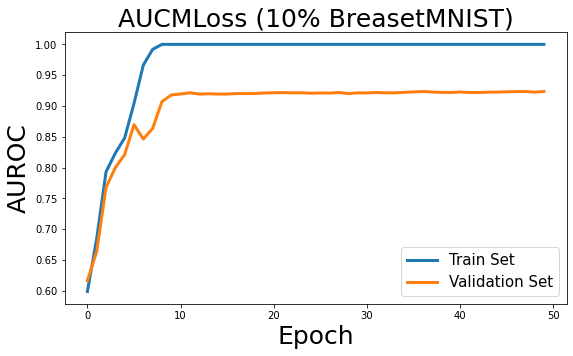

In [68]:
plt.rcParams["figure.figsize"] = (9,5)
x=np.arange(len(train_log))
plt.figure()
plt.plot(x, train_log, linestyle='-', label='Train Set', linewidth=3)
plt.plot(x, val_log,  linestyle='-', label='Validation Set', linewidth=3)
plt.title('AUCMLoss (10% BreasetMNIST)',fontsize=25)
plt.legend(fontsize=15)
plt.ylabel('AUROC', fontsize=25)
plt.xlabel('Epoch', fontsize=25)

In [69]:
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE)

# Testing AUC
score_list = list()
label_list = list()
for _, d in enumerate(test_loader, 0):
    tmp_data, tmp_label = d
    #tmp_data, tmp_label = tmp_data.cuda(), tmp_label.cuda()
    
    tmp_score = model3(tmp_data).detach().clone().cpu()
    #print(tmp_score)
    score_list.append(tmp_score)
    label_list.append(tmp_label.cpu())

test_label = torch.cat(label_list)
test_score = torch.cat(score_list)
                   
test_auc = metrics.roc_auc_score(test_label, test_score)                   
print("Test : %.4f"%test_auc, flush=True)

Test : 0.8411


In [70]:
# Back to Step 2
# two augmentation combination: Flipping, Gaussian Noise, and Normalize
# load more training and validation dataset to create new data using data augmentation
desired_class = [0]
new_combined_train = torch.utils.data.ConcatDataset([create_new_img_by_augmentations(desired_class,
                                                                                     data_transform=data_transform2),
                                                     create_new_img_by_augmentations(desired_class,
                                                                                     data_transform=data_transform3),
                                               create_new_img_by_augmentations(desired_class,
                                                                               data_transform=data_transform4)])
len(new_combined_train)

504

In [71]:
count_diff = int(max(neg_counts, pos_counts) - min(neg_counts, pos_counts))
random_sampler = data.RandomSampler(new_combined_train, num_samples=count_diff)
added_dataloader = data.DataLoader(new_combined_train, batch_size=BATCH_SIZE, sampler=random_sampler)

added_diter = iter(added_dataloader)
examples, labels = next(added_diter)
added_tensors_img, added_tensors_labels = examples, labels
#for i in range(1, ceil(len(combined_train) / BATCH_SIZE)):
for i in range(1, ceil(count_diff / BATCH_SIZE)):
    examples, labels = next(added_diter)
    added_tensors_img = torch.cat([added_tensors_img, examples])
    added_tensors_labels = torch.cat([added_tensors_labels, labels])
    
X = torch.cat([ct_tensors_img, added_tensors_img])
y = torch.cat([ct_tensors_labels, added_tensors_labels])

In [72]:
# splitting train and validation data with balanced ratio
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=7)
len(X_train)

729

In [73]:
train_d = torch.utils.data.TensorDataset(X_train, y_train)
val_d = torch.utils.data.TensorDataset(X_val, y_val)

In [74]:
trainloader = data.DataLoader(dataset=train_d, batch_size=BATCH_SIZE, shuffle=True)
valloader = data.DataLoader(dataset=val_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
trainloader_eval = data.DataLoader(train_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [75]:
# resnet18 model
from libauc.models import resnet18 as ResNet18

#writer = SummaryWriter("runs/breast")
model4 = ResNet18(pretrained=False, last_activation=None, num_classes=1, )
model4.conv1 = torch.nn.Conv2d(1, 64, kernel_size=7, stride=1, padding=3, bias=False)

# HyperParameters
SEED = 123
BATCH_SIZE = 128
imratio = 0.1 # for demo 
total_epochs = 50
decay_epochs = [50, 75]

lr = 0.1
margin = 1.0
epoch_decay = 0.003 # refers gamma in the paper
weight_decay = 0.0001


# loss and optimizer
loss_fn = AUCMLoss()
optimizer = PESG(model4, 
                 loss_fn=loss_fn,
                 lr=lr, 
                 momentum=0.9,
                 #margin=margin)
                 margin=margin, 
                 epoch_decay=epoch_decay, 
                 weight_decay=weight_decay)

#writer.add_graph(model=model)  # graph of model structure
#writer.close()
#sys.exit()



In [76]:
# early stopping patience; how long to wait after last time validation loss improved.
patience = 20

train_log, val_log = train(model4, loss_fn, optimizer, total_epochs, trainloader, trainloader_eval, valloader,
      decay_epochs=decay_epochs)

Start Training
------------------------------
128
128
128
128
128
89
epoch: 0, train_loss: 0.1714, train_auc: 0.3502, val_auc: 0.3251, lr: 0.1000
0
128
128
128
128
128
89
epoch: 1, train_loss: 0.2163, train_auc: 0.5886, val_auc: 0.5852, lr: 0.1000
0
128
128
128
128
128
89
epoch: 2, train_loss: 0.1652, train_auc: 0.7653, val_auc: 0.7451, lr: 0.1000
0
128
128
128
128
128
89
epoch: 3, train_loss: 0.1015, train_auc: 0.8196, val_auc: 0.7731, lr: 0.1000
0
128
128
128
128
128
89
epoch: 4, train_loss: 0.0518, train_auc: 0.8543, val_auc: 0.7831, lr: 0.1000
0
128
128
128
128
128
89
epoch: 5, train_loss: 0.0135, train_auc: 0.8649, val_auc: 0.7828, lr: 0.1000
0
128
128
128
128
128
89
epoch: 6, train_loss: -0.0188, train_auc: 0.9313, val_auc: 0.7876, lr: 0.1000
0
128
128
128
128
128
89
epoch: 7, train_loss: -0.0223, train_auc: 0.9956, val_auc: 0.8630, lr: 0.1000
0
128
128
128
128
128
89
epoch: 8, train_loss: -0.0164, train_auc: 1.0000, val_auc: 0.9023, lr: 0.1000
0
128
128
128
128
128
89
epoch: 9, 

Text(0.5, 0, 'Epoch')

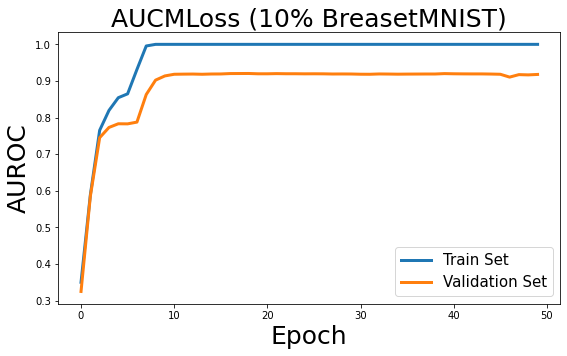

In [77]:
plt.rcParams["figure.figsize"] = (9,5)
x=np.arange(len(train_log))
plt.figure()
plt.plot(x, train_log, linestyle='-', label='Train Set', linewidth=3)
plt.plot(x, val_log,  linestyle='-', label='Validation Set', linewidth=3)
plt.title('AUCMLoss (10% BreasetMNIST)',fontsize=25)
plt.legend(fontsize=15)
plt.ylabel('AUROC', fontsize=25)
plt.xlabel('Epoch', fontsize=25)

In [78]:
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE)

# Testing AUC
score_list = list()
label_list = list()
for _, d in enumerate(test_loader, 0):
    tmp_data, tmp_label = d
    #tmp_data, tmp_label = tmp_data.cuda(), tmp_label.cuda()
    
    tmp_score = model4(tmp_data).detach().clone().cpu()
    #print(tmp_score)
    score_list.append(tmp_score)
    label_list.append(tmp_label.cpu())

test_label = torch.cat(label_list)
test_score = torch.cat(score_list)
                   
test_auc = metrics.roc_auc_score(test_label, test_score)                   
print("Test : %.4f"%test_auc, flush=True)

Test : 0.7274


Data created by augmentation techniques HorizontalFlip and data created by Gaussian Noise generated the top performing ResNet model. So, the dataset we will use for the next steps will be that one.

Combined Step 4 & 5: Optimizer selection. Tune optimizer, batch size, and step size and Hyperparameter tuning. Lastly, model training and testing with the best dataset

In [79]:
# load more training and validation dataset to create new data using data augmentation
desired_class = [0]
new_combined_train = torch.utils.data.ConcatDataset([create_new_img_by_augmentations(desired_class,
                                                                                     data_transform=data_transform2),
                                               create_new_img_by_augmentations(desired_class,
                                                                               data_transform=data_transform3)])
len(new_combined_train)

336

In [80]:
# construct upsampled dataset
count_diff = int(max(neg_counts, pos_counts) - min(neg_counts, pos_counts))
random_sampler = data.RandomSampler(new_combined_train, num_samples=count_diff)
added_dataloader = data.DataLoader(new_combined_train, batch_size=BATCH_SIZE, sampler=random_sampler)

added_diter = iter(added_dataloader)
examples, labels = next(added_diter)
added_tensors_img, added_tensors_labels = examples, labels
#for i in range(1, ceil(len(combined_train) / BATCH_SIZE)):
for i in range(1, ceil(count_diff / BATCH_SIZE)):
    examples, labels = next(added_diter)
    added_tensors_img = torch.cat([added_tensors_img, examples])
    added_tensors_labels = torch.cat([added_tensors_labels, labels])

X = torch.cat([ct_tensors_img, added_tensors_img])
y = torch.cat([ct_tensors_labels, added_tensors_labels])

In [81]:
# splitting train and validation data with balanced ratio
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=7)
len(X_train)

729

In [82]:
train_d = torch.utils.data.TensorDataset(X_train, y_train)
val_d = torch.utils.data.TensorDataset(X_val, y_val)

In [88]:
# resnet18 model
from libauc.models import resnet18 as ResNet18

SEED = 123
imratio = 0.1 # for demo 
total_epochs = 50
decay_epochs = [50, 75]


margin = 1.0
epoch_decay = 0.003 # refers gamma in the paper
weight_decay = 0.0001

# HyperParameters
optmzr = ['adam', 'momentum', 'PESG']
BATCH_SIZE = [64, 128, 256]
lr = [1e-3, 1e-2, 1e-1]

max_auc = 0
best_hyperparams = []  # optimizer, batch_size, lr order
best_model = None
# hyperparameter tuning based on gridsearch
for i in range(len(optmzr)*len(BATCH_SIZE)*len(lr)):
    model_i = ResNet18(pretrained=False, last_activation=None, num_classes=1, )
    model_i.conv1 = torch.nn.Conv2d(1, 64, kernel_size=7, stride=1, padding=3, bias=False)
    
    
    lr_idx = i % len(lr)
    batch_idx = (i // len(lr)) % len(BATCH_SIZE)
    optmzr_idx = i // (len(lr) * len(BATCH_SIZE))
    
    #print(i)
    #print(f"opt: {optmzr_idx}, bat: {batch_idx}, lr: {lr_idx}")
    
    trainloader = data.DataLoader(dataset=train_d, batch_size=BATCH_SIZE[batch_idx], shuffle=True)
    valloader = data.DataLoader(dataset=val_d, batch_size=BATCH_SIZE[batch_idx], shuffle=False, num_workers=2)
    trainloader_eval = data.DataLoader(train_d, batch_size=BATCH_SIZE[batch_idx], shuffle=False, num_workers=2)
    

    # loss and optimizer
    loss_fn = AUCMLoss()

    if optmzr[optmzr_idx] == 'adam':  # use adam optimizer
        #optimizer = torch.optim.Adam(model_i.parameters(), lr=lr[lr_idx], weight_decay=weight_decay)
        optimizer = Adam(model_i,
                 lr=lr[lr_idx],
                 weight_decay=weight_decay)
    elif optmzr[optmzr_idx] == 'momentum':  # use momentous SGD optimzer
        #optimizer = optim.SGD(model_i.parameters(), lr=lr[lr_idx], momentum=0.9)
        optimizer = SGD(model_i, 
                 lr=lr[lr_idx],
                 momentum=0.9,
                 weight_decay=weight_decay)
    else:  # PESG
        optimizer = PESG(model_i, 
                 loss_fn=loss_fn,
                 lr=lr[lr_idx], 
                 momentum=0.9,
                 #margin=margin)
                 margin=margin, 
                 epoch_decay=epoch_decay, 
                 weight_decay=weight_decay)
    
    print(f"optimzer: {optmzr[optmzr_idx]}, step size: {lr[lr_idx]}, batch size: {BATCH_SIZE[batch_idx]}")
    train(model_i, loss_fn, optimizer, total_epochs, trainloader, trainloader_eval, valloader,
          decay_epochs=decay_epochs)

    # evaluate the performance on validation set to select the best hyperparameters
    val_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE[batch_idx], num_workers=2)
    score_list = list()
    label_list = list()
    for _, d in enumerate(val_loader, 0):
        tmp_data, tmp_label = d
        #tmp_data, tmp_label = tmp_data.cuda(), tmp_label.cuda()

        tmp_score = model4(tmp_data).detach().clone().cpu()
        #print(tmp_score)
        score_list.append(tmp_score)
        label_list.append(tmp_label.cpu())

    val_label = torch.cat(label_list)
    val_score = torch.cat(score_list)

    val_auc = metrics.roc_auc_score(val_label, val_score)                   
    print("Test : %.4f"%test_auc, flush=True)
    
    if test_auc > max_auc:
        max_auc = test_auc
        best_hyperparams = [optmzr[optmzr_idx], lr[lr_idx], BATCH_SIZE[batch_idx]]
        best_model = model_i
    '''

0
opt: 0, bat: 0, lr: 0
1
opt: 0, bat: 0, lr: 1
2
opt: 0, bat: 0, lr: 2
3
opt: 0, bat: 1, lr: 0
4
opt: 0, bat: 1, lr: 1
5
opt: 0, bat: 1, lr: 2
6
opt: 0, bat: 2, lr: 0
7
opt: 0, bat: 2, lr: 1
8
opt: 0, bat: 2, lr: 2
9
opt: 1, bat: 0, lr: 0
10
opt: 1, bat: 0, lr: 1
11
opt: 1, bat: 0, lr: 2
12
opt: 1, bat: 1, lr: 0
13
opt: 1, bat: 1, lr: 1
14
opt: 1, bat: 1, lr: 2
15
opt: 1, bat: 2, lr: 0
16
opt: 1, bat: 2, lr: 1
17
opt: 1, bat: 2, lr: 2
18
opt: 2, bat: 0, lr: 0
19
opt: 2, bat: 0, lr: 1
20
opt: 2, bat: 0, lr: 2
21
opt: 2, bat: 1, lr: 0
22
opt: 2, bat: 1, lr: 1
23
opt: 2, bat: 1, lr: 2
24
opt: 2, bat: 2, lr: 0
25
opt: 2, bat: 2, lr: 1
26
opt: 2, bat: 2, lr: 2


In [ ]:
batch_size = best_hyperparams[2]
test_loader = data.DataLoader(dataset=test_dataset, batch_size=batch_size)

# Testing AUC
score_list = list()
label_list = list()
for _, d in enumerate(test_loader, 0):
    tmp_data, tmp_label = d
    #tmp_data, tmp_label = tmp_data.cuda(), tmp_label.cuda()
    
    tmp_score = best_model(tmp_data).detach().clone().cpu()
    #print(tmp_score)
    score_list.append(tmp_score)
    label_list.append(tmp_label.cpu())

test_label = torch.cat(label_list)
test_score = torch.cat(score_list)
                   
test_auc = metrics.roc_auc_score(test_label, test_score)                   
print("Test : %.4f"%test_auc, flush=True)

END

In [276]:
test_data.shape

(156, 28, 28)

In [190]:
'''
# load more training and validation dataset to create new data using data augmentation
desired_class = [0]
train_dataset2 = DataClass(split='train', transform=data_transform2, download=download)
val_dataset2 = DataClass(split='val', transform=data_transform2, download=download)
#combined_train2 = torch.utils.data.ConcatDataset([train_dataset1, val_dataset1])
filtered_trainset = torch.utils.data.Subset(train_dataset2,
                            [i for i in range(len(train_dataset2)) if train_dataset2.labels[i] in desired_class])
filtered_valset = torch.utils.data.Subset(val_dataset2,
                            [i for i in range(len(val_dataset2)) if val_dataset2.labels[i] in desired_class])
combined_train2 = torch.utils.data.ConcatDataset([filtered_trainset, filtered_valset])
'''

Using downloaded and verified file: /Users/chihoonlee/.medmnist/breastmnist.npz
Using downloaded and verified file: /Users/chihoonlee/.medmnist/breastmnist.npz


In [181]:
len(filtered_trainset)

147

In [182]:
train_dataset2.labels

array([[1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
    

In [122]:
len(train_dataset1)

546

In [126]:
len(val_dataset1)

78

In [117]:
ti = iter(train_loader1)
s, l = next(ti)
l.shape

torch.Size([128, 1])

In [ ]:
for i in range():
    

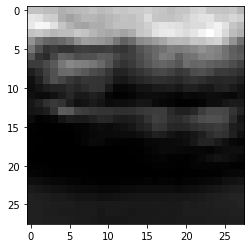

In [79]:
'''
examples1 = iter(train_loader1)
samples1, labels1 = next(examples1)
plt.imshow(samples1[0][0], cmap='gray')
plt.show()
'''

In [172]:
data_transform3 = transforms.Compose([
    transforms.ToTensor(),
    AddGaussianNoise(0., 0.2)
])


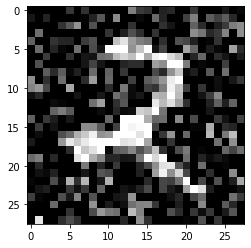

In [173]:
# load MNIST data
train_dataset1 = torchvision.datasets.MNIST(root='./data', train=True,
                                          transform=data_transform1, download=True)
train_dataset2 = torchvision.datasets.MNIST(root='./data', train=False,
                                          transform=data_transform3, download=True)
train_loader1 = torch.utils.data.DataLoader(dataset=train_dataset1, batch_size=BATCH_SIZE, shuffle=True)
train_loader2 = torch.utils.data.DataLoader(dataset=train_dataset2, batch_size=BATCH_SIZE, shuffle=True)
examples1 = iter(train_loader1)
samples1, labels1 = next(examples1)
#noise_imgs = add_noise(samples1[0][0],noise_factor=0.3)

plt.imshow(noise_imgs, cmap='gray')
plt.show()

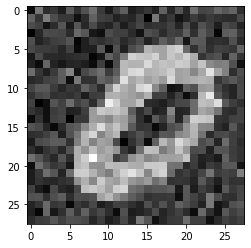

In [174]:
examples2 = iter(train_loader2)
samples2, labels2 = next(examples2)

plt.imshow(samples2[0][0], cmap='gray')
plt.show()